In [8]:
import pandas as pd
import matplotlib.pyplot as plt


In [9]:
titanic = pd.read_csv('data/titanic.csv')
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [54]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
 11  FamilySize   891 non-null    int64  
dtypes: float64(2), int64(6), str(4)
memory usage: 83.7 KB


In [35]:
titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='str')

In [12]:
titanic.shape

(891, 12)

In [13]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [22]:
titanic['Age'].value_counts()

Age
24.00    30
22.00    27
18.00    26
28.00    25
19.00    25
         ..
24.50     1
0.67      1
0.42      1
34.50     1
74.00     1
Name: count, Length: 88, dtype: int64

cabin titile have lot of nan value over 600 by drop removing the column

In [41]:


titanic["Age"] = titanic["Age"].fillna(titanic['Age'].median())
titanic["Embarked"] = titanic["Embarked"].fillna(titanic['Embarked'].mode()[0])

titanic["FamilySize"] = titanic['SibSp'] + titanic['Parch'] + 1
titanic["Age"].isnull().sum()
titanic["Embarked"].isnull().sum()

np.int64(0)

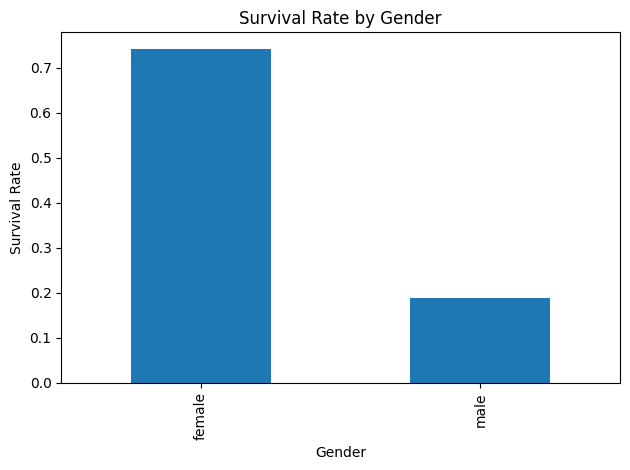

In [49]:
survival_gender = titanic.groupby("Sex")["Survived"].mean()

survival_gender.plot(kind='bar')

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.savefig("plots/Survival_Rate_by_Gender_on_the_Titanic.png")

plt.tight_layout()
 
plt.show()

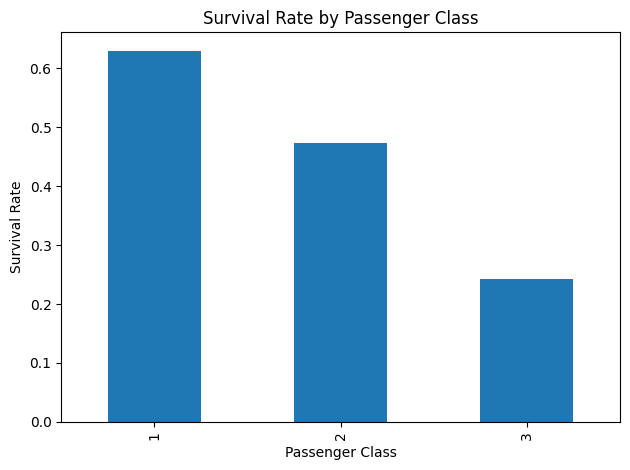

In [50]:
survival_class = titanic.groupby("Pclass")["Survived"].mean()

survival_class.plot(kind='bar')
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.savefig("plots/Survival_Rate_by_Passenger_class_on_the_Titanic.png")

plt.tight_layout()

plt.show()

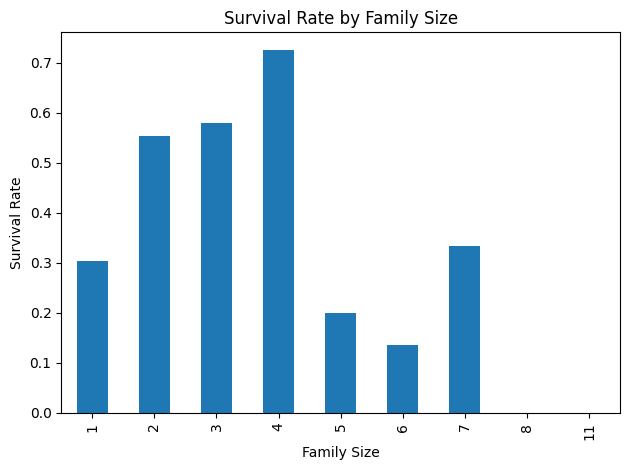

In [51]:
family_survival = titanic.groupby("FamilySize")["Survived"].mean()
family_survival.plot(kind='bar')
plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.savefig("plots/Survival_Rate_by_family_size_on_the_Titanic.png")

plt.tight_layout()

plt.show()

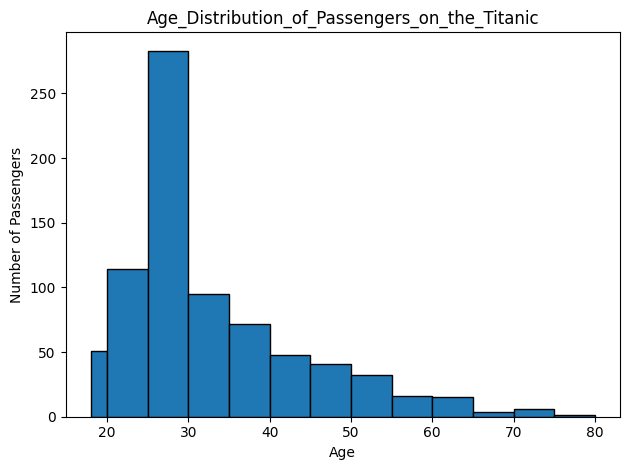

In [52]:
bins=[18,20,25,30,35,40,45,50,55,60,65,70,75,80]
plt.hist(titanic["Age"], bins=bins, edgecolor='black')
plt.title("Age_Distribution_of_Passengers_on_the_Titanic")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.savefig("plots/Age_Distribution_of_Passengers_on_the_Titanic.png")

plt.tight_layout()

plt.show()

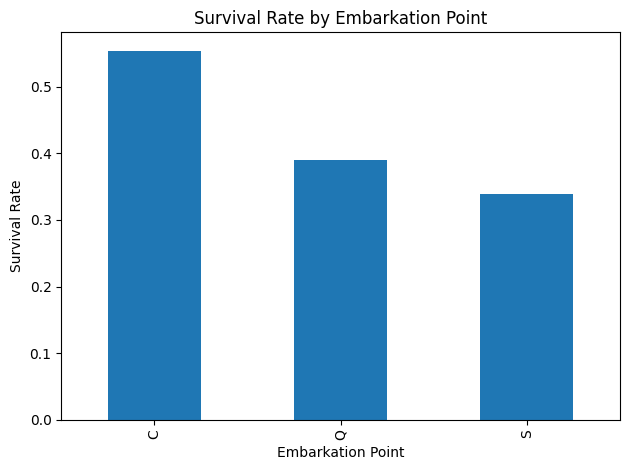

In [55]:
embarked_survival = titanic.groupby("Embarked")["Survived"].mean()

embarked_survival.plot(kind='bar')
plt.title("Survival Rate by Embarkation Point")
plt.xlabel("Embarkation Point")
plt.ylabel("Survival Rate")
plt.savefig("plots/Survival_Rate_by_Embarkation_Point_on_the_Titanic.png")
plt.tight_layout()
plt.show()
